In [67]:
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import treedata as td
import matplotlib.pyplot as plt
import random
import pycea as py

plt.rcParams["figure.figsize"] = (4, 4)

In [68]:
#import petracer

In [69]:
import pycea as py
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["figure.dpi"] = 600
edit_cmap = mcolors.ListedColormap(
    ["white", "lightgray", "#CD2626", "#E69F00", "#FFE600", "#009E73", "#83A4FF", "#1874CD", "#8E0496", "#DB65D2"]
)

# Auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [158]:
import networkx as nx
from Bio import Phylo

def read_newick_file_biopython(file_path):
    """
    从文件读取 Newick 树并转换为有向图
    """
    # 读取 Newick 文件
    tree = Phylo.read(file_path, "newick")
    tree.root_with_outgroup('synthetic')
    
    # 创建有向图
    G = nx.DiGraph()
    
    def traverse(clade, parent=None):
        # 为节点生成唯一标识
        if clade.name:
            node_name = clade.name
        else:
            node_name = f"node_{id(clade)}"
        
        # 添加节点
        G.add_node(node_name, branch_length=clade.branch_length)
        
        # 添加边（从父节点到当前节点）
        if parent is not None:
            G.add_edge(parent, node_name, branch_length=clade.branch_length)
        
        # 递归处理子节点
        for child in clade.clades:
            traverse(child, node_name)
        
        return node_name
    
    traverse(tree.root)
    return G

# 使用示例
tree = read_newick_file_biopython("/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/SPATIAL/T2/trees/bin50_align_reads10/EE_tree/C3-1732.phy.treefile")


In [159]:
leaves = [i for i in tree.nodes if tree.out_degree(i) == 0]
leaves

['10000_10100',
 '10000_9600',
 '10500_9900',
 '10300_9550',
 '10500_9050',
 '11250_9600',
 '11000_8900',
 '9050_8700',
 '9850_10350',
 '10050_8600',
 '9250_6100',
 '10400_9300',
 '10350_8100',
 '11200_8150',
 '2800_3800',
 '4450_10800',
 '2450_3250',
 '6250_8150',
 '7450_8300',
 '6750_8250',
 '7100_8150',
 '8250_6000',
 '3550_3950',
 '2400_2750',
 '2600_4300',
 '6850_9000',
 '6950_8350',
 '6400_8550',
 '8150_8950',
 '7750_8800',
 '2600_3600',
 '3250_3900',
 '8100_8950',
 '6450_3900',
 '6250_7100',
 '10350_10850',
 '11050_9100',
 '10450_8250',
 '11100_8650',
 '3350_4550',
 '7100_4650',
 '9950_3900',
 '9300_6400',
 '2650_3650',
 '2800_4350',
 '3100_3750',
 '3600_3550',
 '2850_3900',
 '2950_4800',
 '10600_8950',
 '9950_9850',
 '10750_8950',
 '10900_10400',
 '11100_8800',
 '5900_10500',
 '10050_7100',
 '9800_7100',
 '10400_6700',
 '10750_9450',
 '6250_7850',
 '3800_5600',
 '9050_4100',
 '8600_5650',
 '9500_6200',
 '10200_10300',
 '3150_7750',
 '10650_5300',
 '5800_4350',
 '10850_6400',
 '

In [160]:
len(leaves)

1732

In [161]:
#tree = nx.relabel_nodes(tree, {j: f"Cell_{i}" for i, j in enumerate(leaves)})
nx.set_node_attributes(tree, "lightblue", "color")

In [162]:
adata = sc.read_h5ad('/syn1/liangzhen/jinhua_jilab_project/result/SPATIAL/T2/B03203C612.tissue.bin50.h5ad')
adata 

AnnData object with n_obs × n_vars = 35729 × 25254
    obs: 'orig.ident', 'x', 'y'
    uns: 'sn'
    obsm: 'spatial'

In [163]:
adata.obsm['spatial']

array([[ 1650,  2550],
       [ 1650,  2600],
       [ 1650,  2650],
       ...,
       [11650,  7150],
       [11650,  7600],
       [11650,  7650]], dtype=uint32)

In [164]:
adata.obs['x_y'] = adata.obs['x'].astype('str') + '_' + adata.obs['y'].astype('str')
adata.obs

,orig.ident,x,y,x_y
7086696040950,sample,1650,2550,1650_2550
7086696041000,sample,1650,2600,1650_2600
7086696041050,sample,1650,2650,1650_2650
7086696041100,sample,1650,2700,1650_2700
7086696041150,sample,1650,2750,1650_2750
...,...,...,...,...
50036369005050,sample,11650,6650,11650_6650
50036369005500,sample,11650,7100,11650_7100
50036369005550,sample,11650,7150,11650_7150
50036369006000,sample,11650,7600,11650_7600


In [165]:
adata.obs_names = adata.obs['x_y'].to_list()

In [166]:
adata_sub = adata[[ leaf for leaf in leaves if leaf != 'synthetic' ],:]
adata_sub

View of AnnData object with n_obs × n_vars = 1731 × 25254
    obs: 'orig.ident', 'x', 'y', 'x_y'
    uns: 'sn'
    obsm: 'spatial'

In [167]:
import anndata as ad
import numpy as np
import pandas as pd

def add_zero_cell(adata, cell_name="zero_cell", obs_metadata=None):
    """
    向 AnnData 对象添加一个全零表达的合成细胞
    """
    
    # 1. 全零表达谱
    expression_profile = np.zeros(adata.n_vars)
    new_X = expression_profile.reshape(1, -1)
    
    # 2. 准备新的 obs 数据
    if obs_metadata is None:
        new_obs = pd.DataFrame({
            'cell_type': ['zero'],
            'batch': ['zero_batch'],
            'is_synthetic': ['True'],
            'n_genes_by_counts': [0],
            'total_counts': [0]
        }, index=[cell_name])
    else:
        new_obs = pd.DataFrame([obs_metadata], index=[cell_name])
        new_obs['is_synthetic'] = 'True'
    
    # 3. 创建新的 AnnData
    new_adata = ad.AnnData(
        X=new_X,
        obs=new_obs,
        var=adata.var.copy()
    )
    
    # 4. 合并
    adata_new = ad.concat([adata, new_adata], axis=0)
    
    return adata_new

# 使用示例
adata_sub = add_zero_cell(adata, cell_name="synthetic")

In [168]:
adata_sub

AnnData object with n_obs × n_vars = 35730 × 25254

In [169]:
adata_sub._X = adata_sub.X

In [170]:
tdata = td.TreeData(adata_sub, allow_overlap = True)

In [171]:
tdata

TreeData object with n_obs × n_vars = 35730 × 25254

In [172]:
tdata.obst['tree'] = tree

In [173]:
py.pp.add_depth(tdata,key_added='time')

In [174]:
#total_time = 10
#for node in tdata.obst["tree"].nodes:
#    tdata.obst["tree"].nodes[node]['time'] = tdata.obst["tree"].nodes[node]['time'] * total_time

In [181]:
py.tl.clades(tdata, depth=3, depth_key="time", update=False)

In [ ]:
clade_palette = py.get.palette(tdata, key="clade", cmap="rainbow")

In [260]:
ax = py.pl.tree(
    tdata,
    depth_key="time",
    branch_color="clade",
    palette=clade_palette,
    extend_branches=True,
    branch_linewidth=0.5
)
#ax.legend()
plt.gcf().savefig('IE_spatial_clone3_tree_clade_plots_standard.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [210]:
ax = py.pl.tree(
    tdata,
    depth_key="time",
    branch_color="clade",
    palette=clade_palette,
    angled_branches=True,
    #branch_linewidth=0.5,
)
plt.gcf().savefig('IE_spatial_clone3_tree_clade_plots_angled.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [209]:
ax = py.pl.branches(
    tdata,
    depth_key="time",
    angled_branches=True,
    polar=True,
    color="clade",
    palette=clade_palette,
    linewidth=0.5
)
plt.gcf().savefig('IE_spatial_clone3_tree_clade_plots_polar.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [212]:
tdata.obs['x'] = [
    int(cell.split('_')[0]) if cell != 'synthetic' else 10000
    for cell in tdata.obs.index
]

tdata.obs['y'] = [
    int(cell.split('_')[1]) if cell != 'synthetic' else 10000 
    for cell in tdata.obs.index
]

tdata.obsm['spatial'] = np.array(tdata.obs[['x','y']])

In [213]:
plt.rcParams["figure.figsize"] = (2, 2)

In [214]:
clades = tdata.obs['clade'].unique()

In [215]:
clade_palette = py.get.palette(tdata, key="clade", cmap="rainbow")
clade_palette

{'0': '#8000ff',
 '1': '#6c1fff',
 '2': '#5641fd',
 '3': '#4062fa',
 '4': '#2c7ef7',
 '5': '#169bf2',
 '6': '#00b5eb',
 '7': '#14cae5',
 '8': '#2adddd',
 '9': '#40ecd4',
 '10': '#54f6cb',
 '11': '#6afdc0',
 '12': '#80ffb4',
 '13': '#94fda8',
 '14': '#abf69b',
 '15': '#c0eb8d',
 '16': '#d4dd80',
 '17': '#ebca70',
 '18': '#ffb360',
 '19': '#ff9b52',
 '20': '#ff7e41',
 '21': '#ff5f30',
 '22': '#ff4121',
 '23': '#ff1f10',
 '24': '#ff0000'}

In [216]:
clades

[NaN, '2', '0', '18', '1', ..., '23', '22', '24', '12', '16']
Length: 26
Categories (25, object): ['0' < '1' < '2' < '3' ... '21' < '22' < '23' < '24']

In [246]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# 获取所有 clade
clades = tdata.obs['clade'].unique()

# 收集所有 figure
figures = []
for clade in clades:
    if pd.isna(clade):
        continue
    
    fig, ax = plt.subplots(figsize=(2, 2))
    
    # 背景点
    ax.scatter(tdata.obs['x'], tdata.obs['y'],
               c='#f0f0f0', s=0.5)
    
    # 当前 clade
    subset = tdata.obs[tdata.obs['clade'] == clade]
    ax.scatter(subset['x'], subset['y'],  
              c=clade_palette[clade], s=0.5, label=clade)
    
    ax.axis('off')
    ax.set_aspect('equal')
    #ax.legend(loc='upper right')
    ax.set_title(f'Clade: {clade}')
    
    figures.append(fig)

# 保存所有图到一个 PDF
with PdfPages('IE_spatial_clone3_clade_umap_plots_split.pdf') as pdf:
    for fig in figures:
        pdf.savefig(fig, dpi=300)
        plt.close(fig)

print(f"Saved {len(figures)} plots to clade_plots.pdf")

Saved 25 plots to clade_plots.pdf


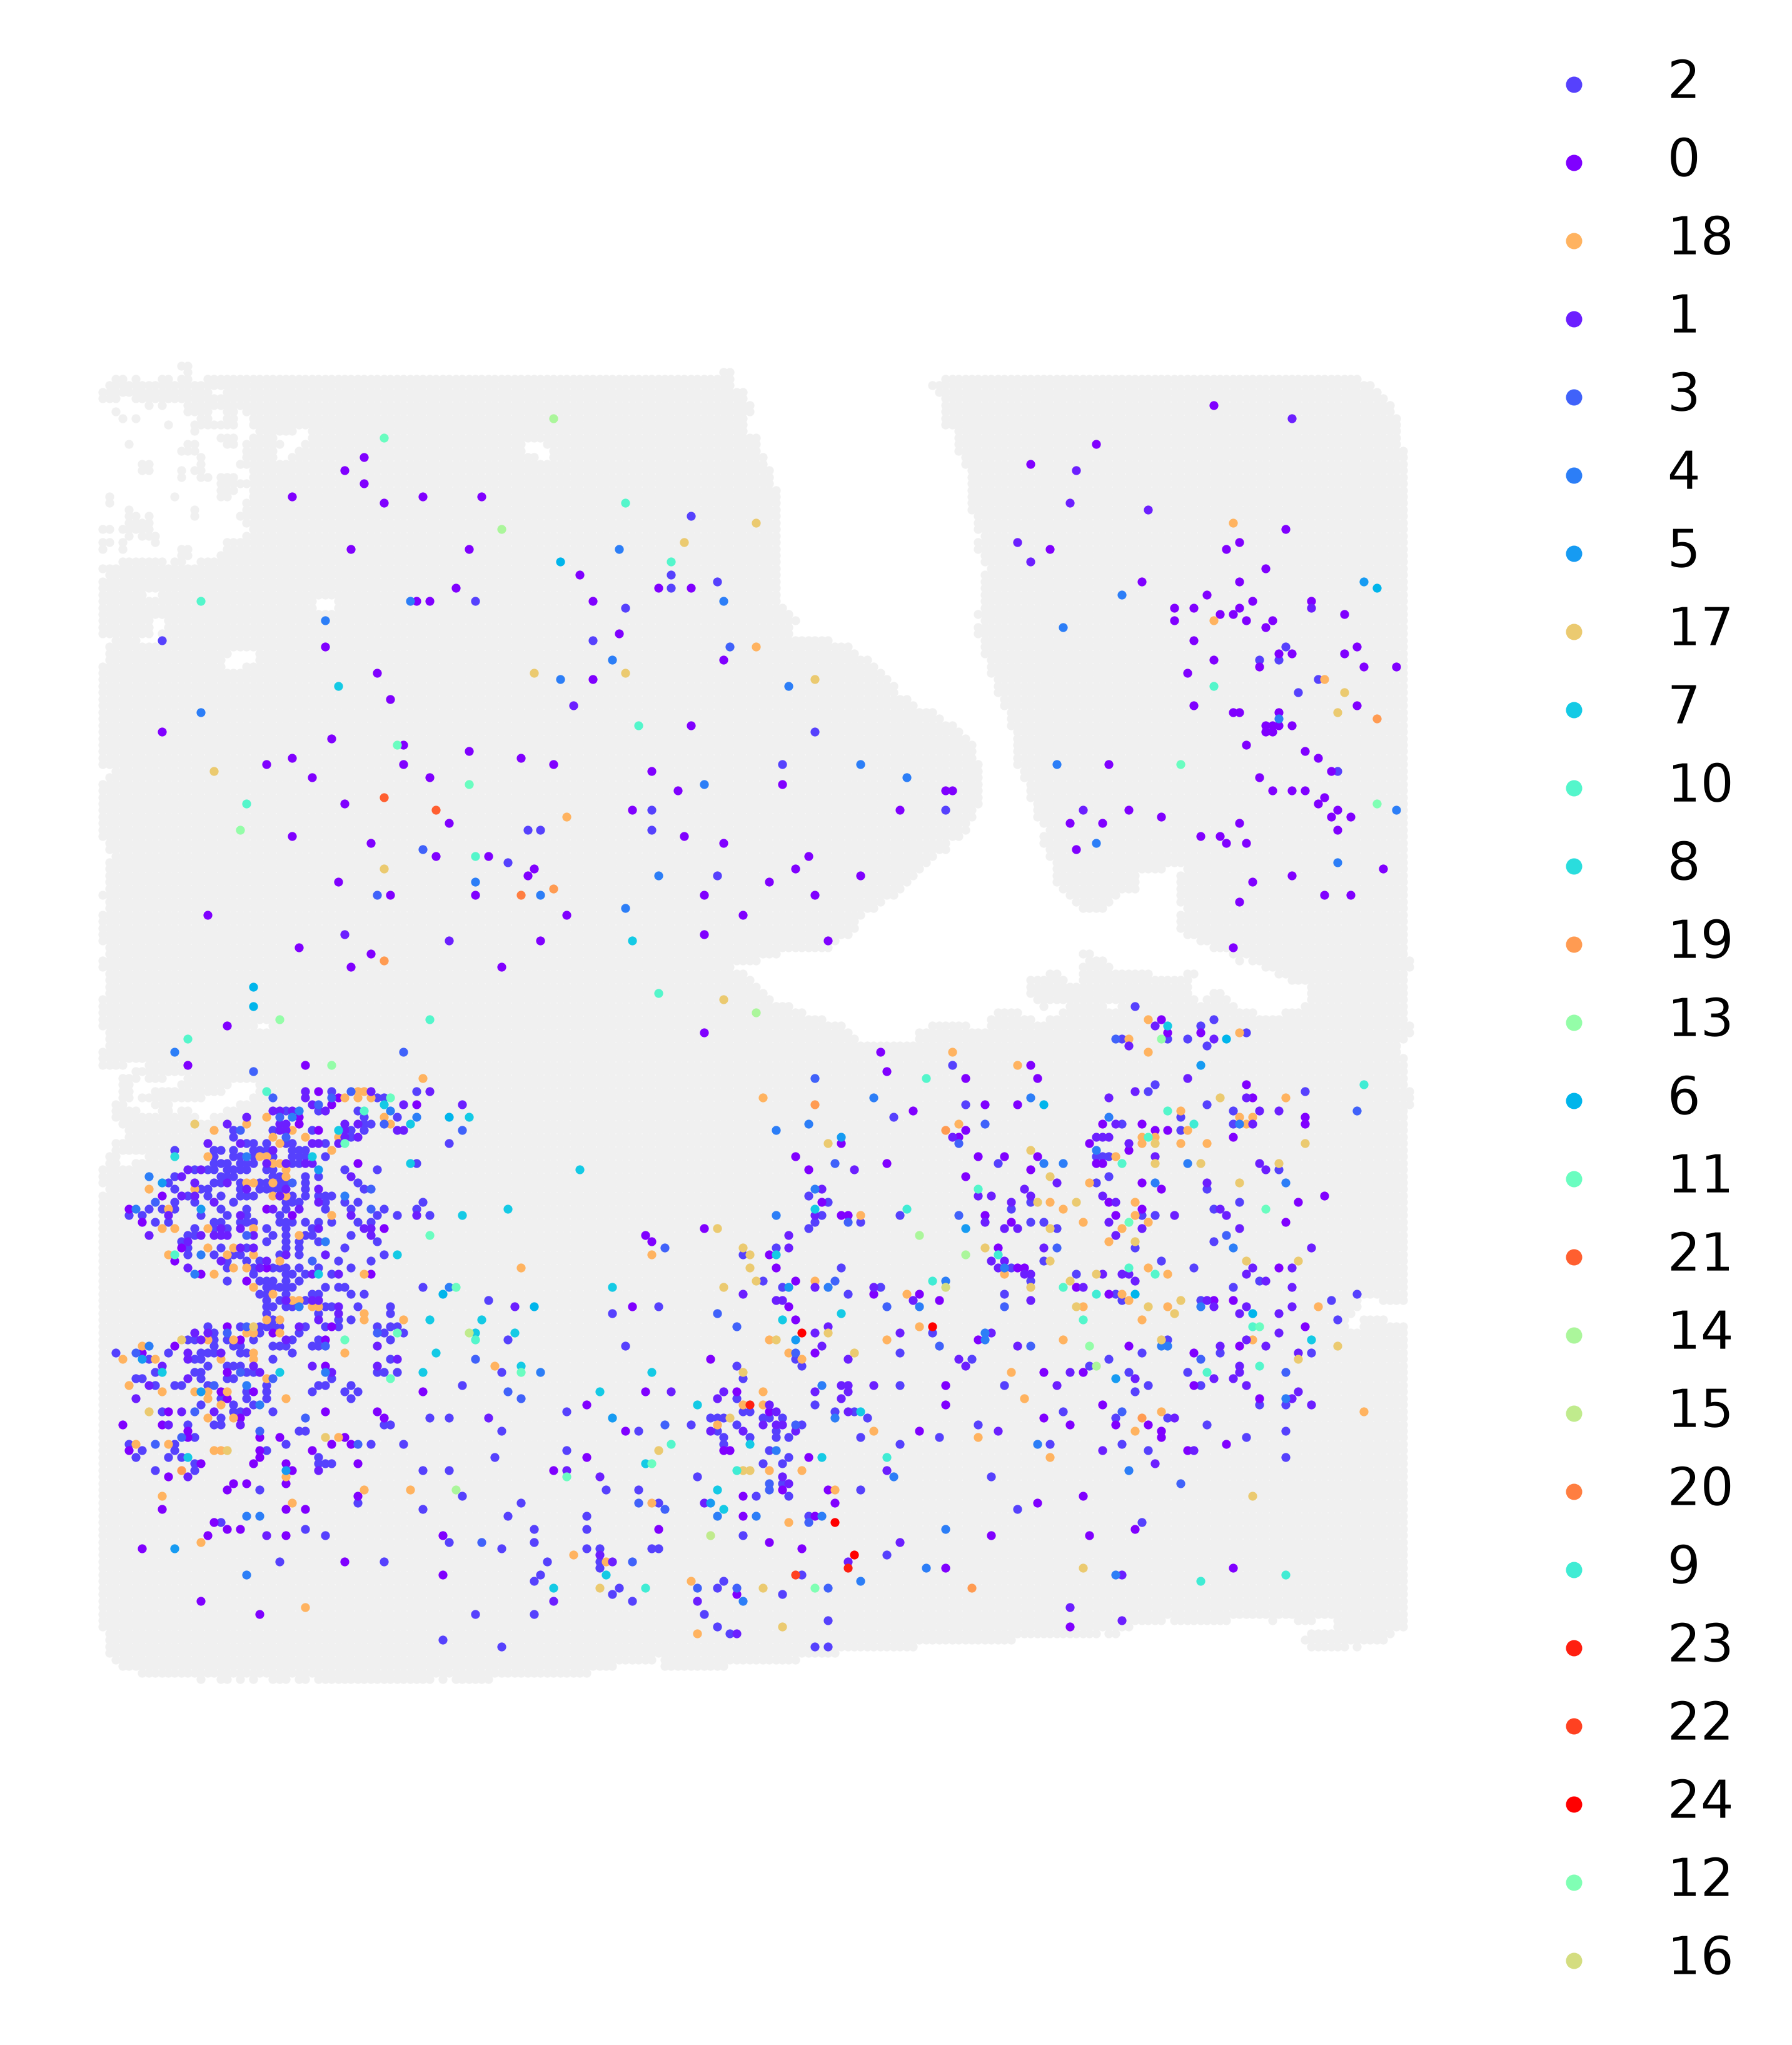

In [266]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# 获取所有 clade
clades = tdata.obs['clade'].unique()
fig, ax = plt.subplots(figsize=(5, 5))

# 背景点
ax.scatter(tdata.obs['x'], tdata.obs['y'],
          c='#f0f0f0', s=0.5)

for clade in clades:
    if pd.isna(clade):
        continue
    
    
    # 当前 clade
    subset = tdata.obs[tdata.obs['clade'] == clade]
    ax.scatter(subset['x'], subset['y'],  
              c=clade_palette[clade], s=0.5, label=clade)
    
    ax.axis('off')
    ax.set_aspect('equal')
    #ax.legend(loc='upper right')
    #ax.set_title(f'Clade: {clade}')


# 隐藏图例
ax.legend(loc='center left', 
          bbox_to_anchor=(1, 0.5),
          frameon=False,
          markerscale=3)
plt.gcf().savefig('IE_spatial_clone3_tree_clade_umap_merge.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
tdata.obs['clade'].unique()

In [65]:
tree

In [208]:
tdata = td.read_h5td('/syn1/liangzhen/jinhua_jilab_project/test/koblan25_tumor.h5td')
tdata

TreeData object with n_obs × n_vars = 145954 × 175
    obs: 'sample', 'cell', 'cellBC', 'fov', 'centroid_x', 'centroid_y', 'centroid_z', 'n_layers', 'volume', 'n_genes_by_counts', 'total_counts', 'cell_subtype', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'total_density', 'tumor', 'tumor_boundary_dist', 'within_tumor', 'lung_boundary_dist', 'type', 'clone', 'detection_rate', 'tree', 'fitness', 'clade', 'character_dist_of_relatives', 'local_character_diversity', 'hotspot_module', 'phase', 'edit_frac', 'leiden_cluster'
    uns: 'clone_characters', 'clone_colors', 'hotspot_module_colors', 'leiden_cluster_colors', 'within_tumor_colors'
    obsm: 'X_resolVI', 'X_umap', 'characters', 'module_scores', 'resolvi_celltypes', 'spatial', 'spatial_grid', 'spatial_overlay', 'subtype_density'
    obst: 'tree'

In [218]:
print(tdata.obst['tree'])

DiGraph with 16890 nodes and 16889 edges


In [216]:
tdata.obs.columns

Index(['sample', 'cell', 'cellBC', 'fov', 'centroid_x', 'centroid_y',
       'centroid_z', 'n_layers', 'volume', 'n_genes_by_counts', 'total_counts',
       'cell_subtype', 'true_proportion', 'diffusion_proportion',
       'background_proportion', 'total_density', 'tumor',
       'tumor_boundary_dist', 'within_tumor', 'lung_boundary_dist', 'type',
       'clone', 'detection_rate', 'tree', 'fitness', 'clade',
       'character_dist_of_relatives', 'local_character_diversity',
       'hotspot_module', 'phase', 'edit_frac', 'leiden_cluster'],
      dtype='object')

In [198]:
#py.pp.add_depth(tdata,key_added='time')

In [213]:
py.tl.clades(tdata, depth=5, depth_key="time", update=False)

<Axes: >

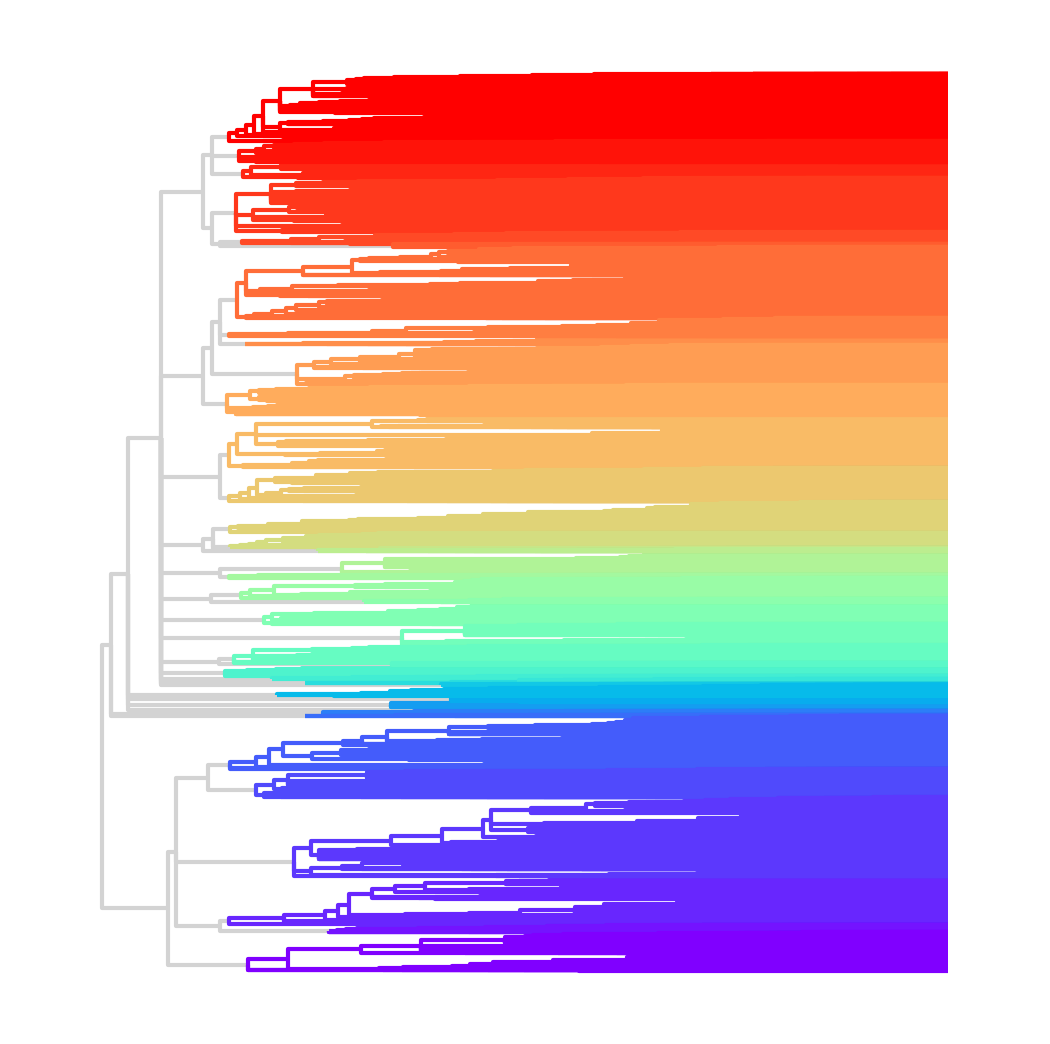

In [214]:
clade_palette = py.get.palette(tdata, key="clade", cmap="rainbow")
py.pl.tree(tdata, depth_key="time", branch_color="clade", palette=clade_palette)

In [185]:
tdata.obs

,sample,cell,cellBC,fov,centroid_x,centroid_y,centroid_z,n_layers,volume,n_genes_by_counts,...,detection_rate,tree,fitness,clade,character_dist_of_relatives,local_character_diversity,hotspot_module,phase,edit_frac,leiden_cluster
M3-1-12,M3-1,12,M3-1-12,0,5439.054260,-3158.591631,-4.316500,20,1294.579646,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN
M3-1-19,M3-1,19,M3-1-19,0,5490.912377,-3126.009492,-9.300944,15,401.667557,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN
M3-1-20,M3-1,20,M3-1-20,0,5430.018624,-3105.313153,-11.427725,9,261.641707,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN
M3-1-45,M3-1,45,M3-1-45,0,5487.063911,-3015.669361,-11.561148,8,428.870381,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN
M3-1-52,M3-1,52,M3-1-52,0,5424.880997,-3121.139758,-6.576749,13,581.426016,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M3-4-78058,M3-4,78058,M3-4-78058,92,5499.118972,-2915.008057,7.490620,11,107.217595,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN
M3-4-78066,M3-4,78066,M3-4-78066,92,5493.331364,-2941.221977,9.720510,10,181.132339,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN
M3-4-78067,M3-4,78067,M3-4-78067,92,5474.905059,-2936.389172,9.123960,10,383.037744,13,...,0.357143,NaN,NaN,NaN,NaN,NaN,1,G2/M,NaN,1
M3-4-78076,M3-4,78076,M3-4-78076,92,5468.022510,-2861.013421,6.304672,6,187.556342,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G0/G1,NaN,NaN


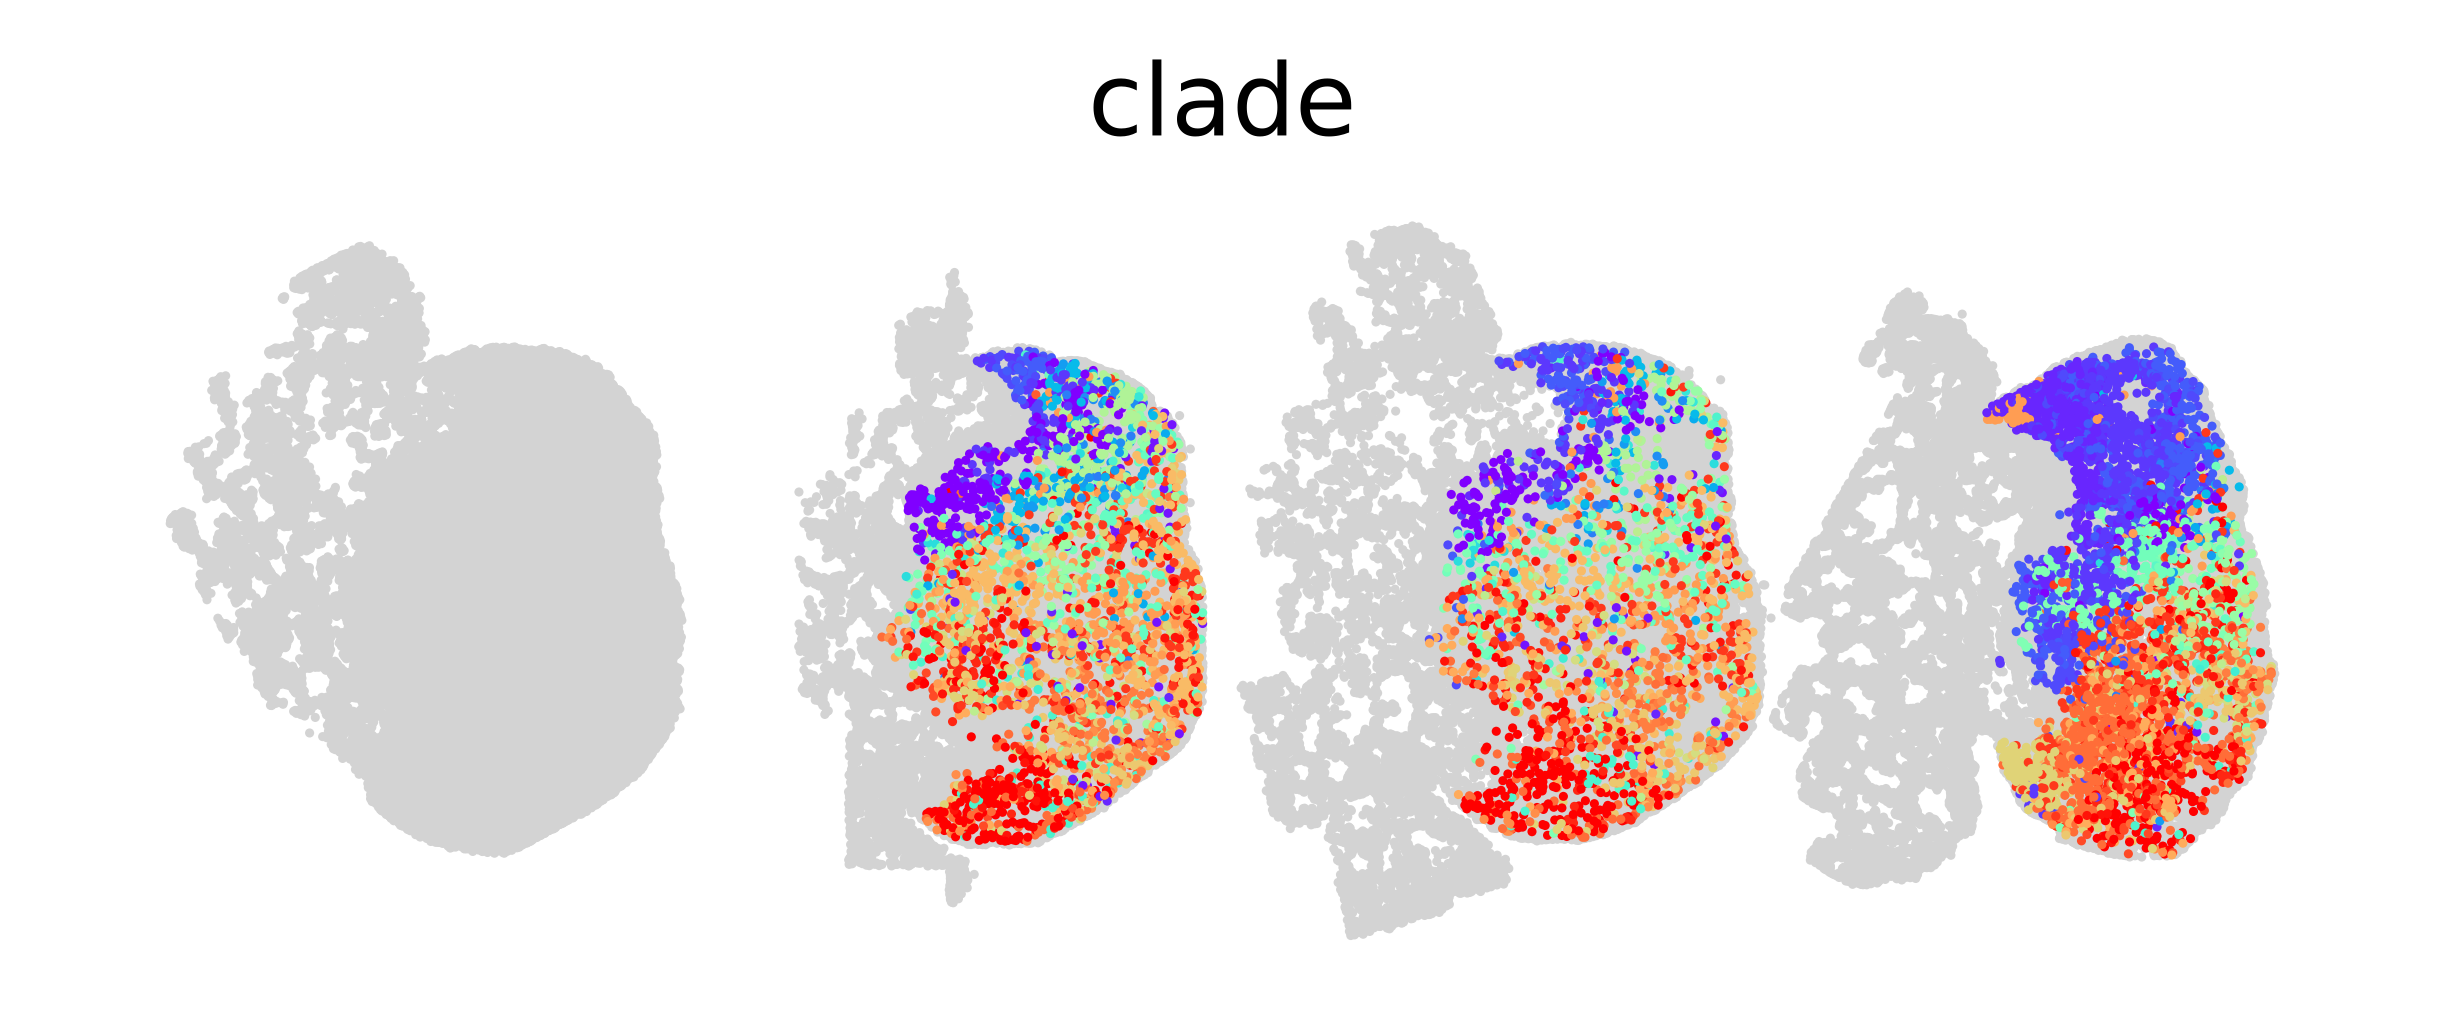

In [14]:
sc.pl.spatial(tdata, color="clade", spot_size=40, frameon=False, legend_loc=None);